In [1]:
# Quantum correction calculations to the linear E and in B magnetoconductivity. Positional shift formalism.
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Field_Induced_Hall_Effect
using Brillouin
using Bravais
using CairoMakie, BZpaths

In [2]:
pathof(Optics_in_the_length_gauge)

"/Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/T9oIl/src/Optics_in_the_length_gauge.jl"

In [3]:
# using Pkg
# Pkg.add(url="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")

## Bands

In [32]:

Γ = [0,0,0]
A = [0,0, π]
M = 2π/3 * [1, 0, 0]
K = 2π/3 * [1, 1/sqrt(3), 0]

function bands(q, p, i)
    mat = ferroaxial_ham3d(q,p.μ,p.Δ,p.t,p.tp, p.tpz, p.tc)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial(p; a = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    # Rs = (a .* [3/2, √3/2, 0], a .* [-3/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
    sgnum = 143                           # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tp) eV")
    for i in 1:2
        dispersion(q) = bands(q, p, i)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end



function bands_ferroaxial_Gamma_M_K(p; a = 1)
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
                 # point group (144 = p3_1)
    N = 200    #kpoints

    mysimpath = [Γ, M, K, Γ .+ 1e-4, A .+ 1e-3, K]
    ks = interpolate(mysimpath, N)
    ticks_vals = [bands(kpoint, p, 1) for kpoint in mysimpath]
    xvals = 1:length(ks)
    
    yvals_1 = [bands(k, p, 1) for k in ks]
    
    yvals_2 = [bands(k, p, 2) for k in ks]
    
    position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "μ = $(p.μ) eV, Δ = $(p.Δ) eV, t_perp = $(p.tpz) eV, t = $(p.t) eV, t2 = $(p.tc), t3 = $(p.tp) eV",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :black)
    lines!(ax, xvals, yvals_2, color = :black)
    ylims!(ax, -10,9)
    ax.yticks = (-10:9, string.(-10:9))
    xvals, fig
end

# Γ = [0,0,0]
# A = [0,0,π]
# M = 2π/3*[1,0,0]
# K = 2π/3*[1, 1/sqrt(3), 0]
# ks = interpolate(mysimpath, N)


bands_ferroaxial_Gamma_M_K (generic function with 1 method)

In [33]:
modelpresets_FA(; μ =1.75, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25)

FerroAxialHam
  μ: Float64 1.75
  t: Float64 1.0
  tp: Float64 1.0
  Δ: Float64 1.0
  tpz: Float64 0.5
  tc: Float64 0.25


[1, 33, 51, 88, 136, 51]


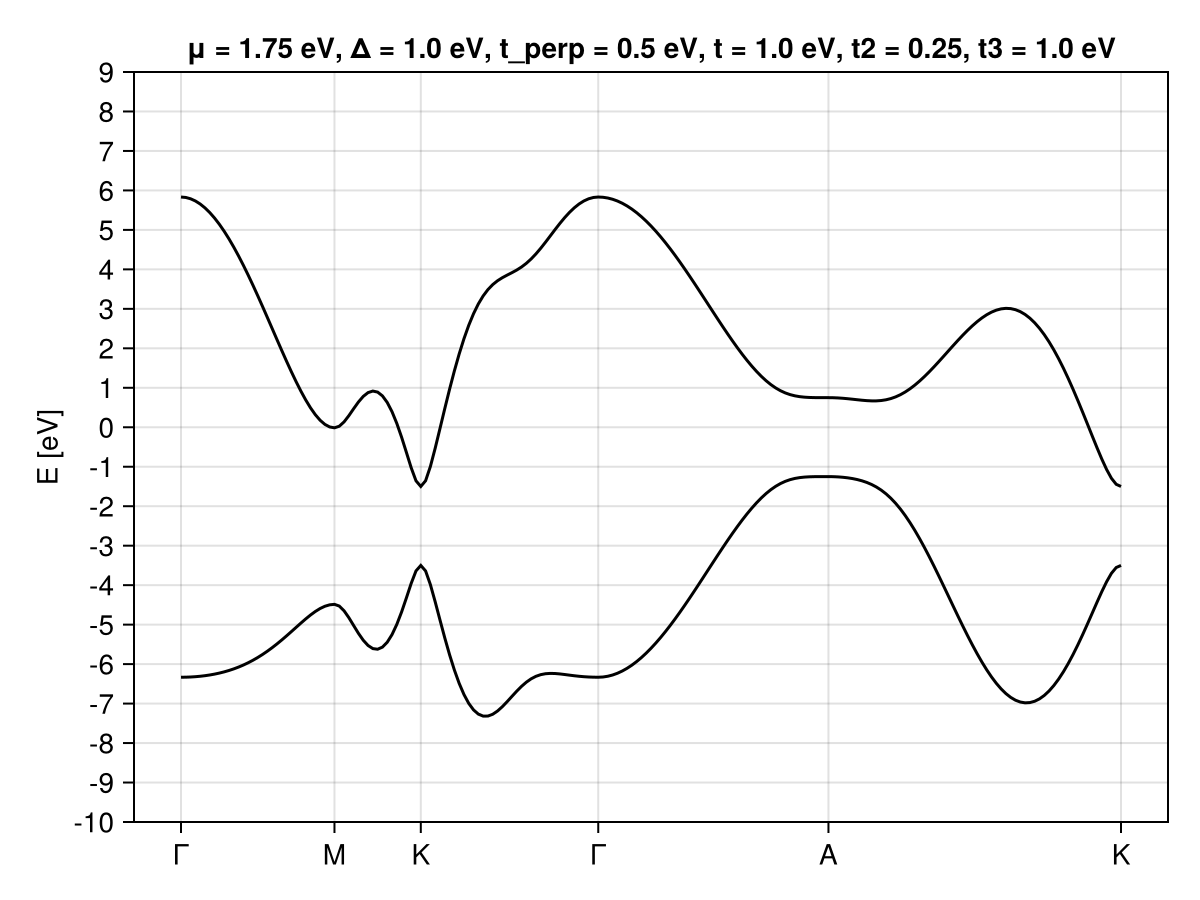

In [34]:
vals, fig = bands_ferroaxial_Gamma_M_K(modelpresets_FA(; μ =1.75, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25));
fig

## Calculations

In [10]:
evals = 200
mu = 0
murange = collect(0:0.5:3)
xbounds = 1 .* [-0.5,-0.5, -0.5]
T = 10
kws = (dirj = :x, dirE = :z, dirB = :x, T = T,
    evals = evals, integration_method = :montecarlo, fermi_surface = false, botbounds =xbounds, 
    topbounds = -xbounds, omega_MM_switch = false, PS_switch = true, QM_switch = true)
#_________________________________________________________________________________________

p = modelpresets_FA(; μ =3, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.5)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...)

Quantum_correction_σijk_antisym{StaticArraysCore.SVector{3, Vector{Float64}}, Field_Induced_Hall_Effect.var"#h#73"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dh#77"{Field_Induced_Hall_Effect.var"#dhz#76"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhy#75"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhx#74"{FerroAxialHam}}, Field_Induced_Hall_Effect.var"#ddh#79"{Field_Induced_Hall_Effect.var"#didjh#78"{FerroAxialHam}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol z
  dirB: Symbol x
  h: h (function of type Field_Induced_Hall_Effect.var"#h#73"{FerroAxialHam})
  nabla_h: dh (function of type Field_Induced_Hall_Effect.var"#dh#77"{Field_Induced_Hall_Effect.var"#dhz#76"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhy#75"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhx#74"{FerroAxialHam}})
  nabla_nabla_h: ddh (function of type Field_Induced_Hall_Effect.var"#ddh#79"{Field_Induced_Hall_Effect.var"#didjh#78"{FerroAxialHam}})
  gs: StaticArraysCore.SVector{3, Vector{Float64}

In [11]:
σ_ijk_A1_qc =  quantum_contribution(comp_pres) #22.1 #15 # 17

Montecarlo integration


3.3063296027411488e-6

### Integral sweeps - Classical and Quantumm

In [4]:
musweep_classical(murange; kws...) = musweep(murange, classical_contribution_sigmaijk; kws...)
musweep_quantum(murange; kws...) = musweep(murange, quantum_contribution; kws...)
function musweep(murange, func; T = 10, evals = 5000, t = 1, tp = 0, tpz =0, tc = 0.3, Δ = 1, fs = false, oswitch = false, psswitch = true, qmswitch = true)
    s = []
    for mu in murange
        comp_pres = sigma_abc_ferroaxial_wrapper_3d(modelpresets_FA(; μ = mu, t = t ,tp = tp, tpz= tpz, tc =tc, Δ = Δ), 
            dirj = :x, dirE = :z, dirB = :x, T = T, τ =10, evals = evals, integration_method = :montecarlo, 
            fermi_surface = fs, botbounds = [-0.5,-0.5,-0.5], topbounds = [0.5,0.5,0.5],
            omega_MM_switch = oswitch, PS_switch = psswitch, QM_switch = qmswitch);
        push!(s, func(comp_pres))
    end
    return murange, s
end

musweep (generic function with 1 method)

In [10]:
kws = (T = 1000, evals = 40000, t = 1 ,tp = 1, Δ =1, tpz = 0.5, tc = 0.5, 
    fs = false, oswitch = false, psswitch = false, qmswitch = true)


(T = 1000, evals = 40000, t = 1, tp = 1, Δ = 1, tpz = 0.5, tc = 0.5, fs = false, oswitch = false, psswitch = false, qmswitch = true)

#### Classical

In [11]:
# classical
musclassical, sumsclassical = musweep_classical(range(-10,10, length = 201); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo 

(-10.0:0.1:10.0, Any[4.8701503245415395e-26, 1.554247527305499e-25, 4.9601864730165265e-25, 1.5829814373103478e-24, 5.051887150816564e-24, 1.6122465610180177e-23, 5.145283130669699e-23, 1.642052719159524e-22, 5.240405754208592e-22, 1.672409914025057e-21  …  -0.15609392932015684, -0.04823678957913441, -0.014511761824927236, -0.004454339664913389, -0.0013852790581357463, -0.00043299692575743973, -0.00013557047493022425, -4.2469745907166995e-5, -1.3306629534235965e-5, -4.169458538654382e-6])

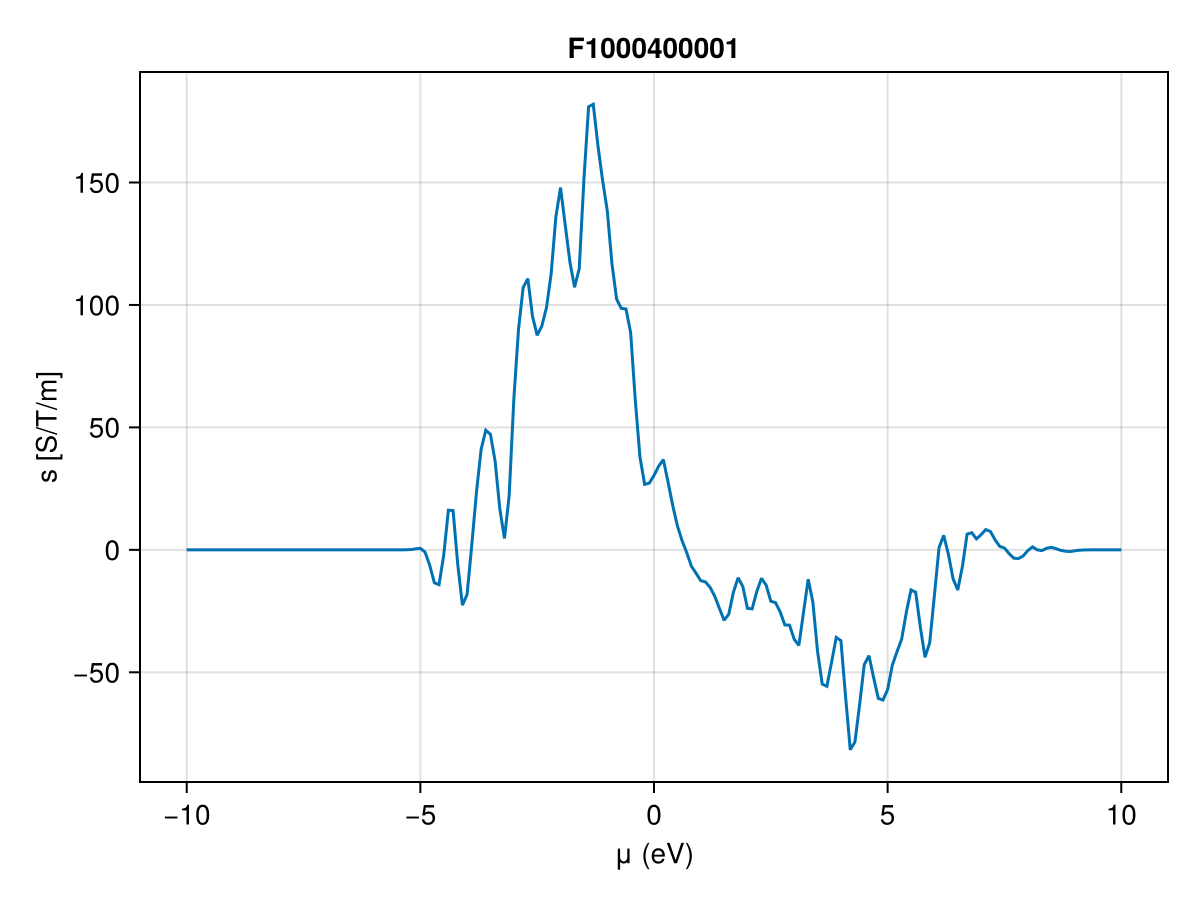

In [15]:
fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ (eV)", 
   ylabel = "s [S/T/m]", title = "F$(kws[1])$(kws[2])$(kws[3])")
lines!(ax, [mu for mu in musclassical], [s for s in sumsclassical])
fig

#### Quantum

In [18]:
musquantum, sumsquantum = musweep_quantum(range(0,3, length = 5); kws...)

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration


(0.0:0.75:3.0, Any[0.0, 0.0, 0.0, 0.0, 0.0])

In [ ]:
# fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ (eV)", 
#    ylabel = "s [S/T/m]", title = "F$(kws[1])$(kws[2])$(kws[3])")
scatter!(ax, [mu for mu in musquantum], [s for s in sumsquantum])
fig

## Fij line

In [69]:

using PhysicalConstants
using PhysicalConstants.CODATA2018
using Unitful
using SparseArrays
using StaticArrays
using Parameters
ħ = PhysicalConstants.CODATA2018.ħ
e = PhysicalConstants.CODATA2018.e


Fij_Gamma_M_K(p, comp_pres, dirF1, dirF2, band; a = 1) = Oij_Gamma_M_K(Optics_in_the_length_gauge.F,p,  comp_pres, dirF1, dirF2, band, a = a )
function Oij_Gamma_M_K(func, p, comp_pres, dirF1, dirF2, band; a = 1)
    N = 400    #kpoints
    mysimpath = [Γ, M .+ 1e-3 , K .+ 1e-3, Γ .+ 1e-3, A .+ 1e-3 , K]
    Fab(comp_pres, q, band) = func(comp_pres, q, dirF1, dirF2)[band]
    ks = interpolate(mysimpath, N)
    ticks_vals = [Fab(comp_pres, kpoint, 1 ) for kpoint in mysimpath]
    units = (e/ħ |> u"T^-1*Å^-2").val # Fab is computed in Å^3 so the result is Å/T
    xvals = 1:length(ks)
    yvals_1 = [Fab(comp_pres, q, 1 ) for q in ks]./units
    yvals_2 = [Fab(comp_pres, q, 2) for q in ks]./units
    
    # position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    position =  [1, 66, 103, 178, 275, 398]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "F$(dirF1)$(dirF2) [Å/T]",  title = "Δ = $(p.Δ) eV, t_perp = $(p.tpz) eV, t = $(p.t) eV, t2 = $(p.tc), t3 = $(p.tp) eV, QM on = $(comp_pres.QM_switch)",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :red, label = "Lower band")
    scatter!(ax, xvals, yvals_1, color = :red)#, label = "Lower band")
    lines!(ax, xvals, yvals_2, color = :black, label = "Uper band")
    
    xlims!(ax, 1, N)
    if maximum(abs.(yvals_1))< 1e-6
        ylims!(ax, -1e-7,1e-7)
    end
    # ylims!(ax, -0.025,0.025)
    axislegend(ax, position = :lt)
    return yvals_1, yvals_2, fig
end






Oij_Gamma_M_K (generic function with 1 method)

In [71]:
band = 1
a = 1.0
R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)
Rs = [R1,R2,R3]

p = modelpresets_FA(; μ = 1, t = 1 ,tp = 1, Δ =1, tpz = 0.5, tc = 0)
kws = (fermi_surface = false, QM_switch = true)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);


[1, 66, 103, 178, 275, 398]


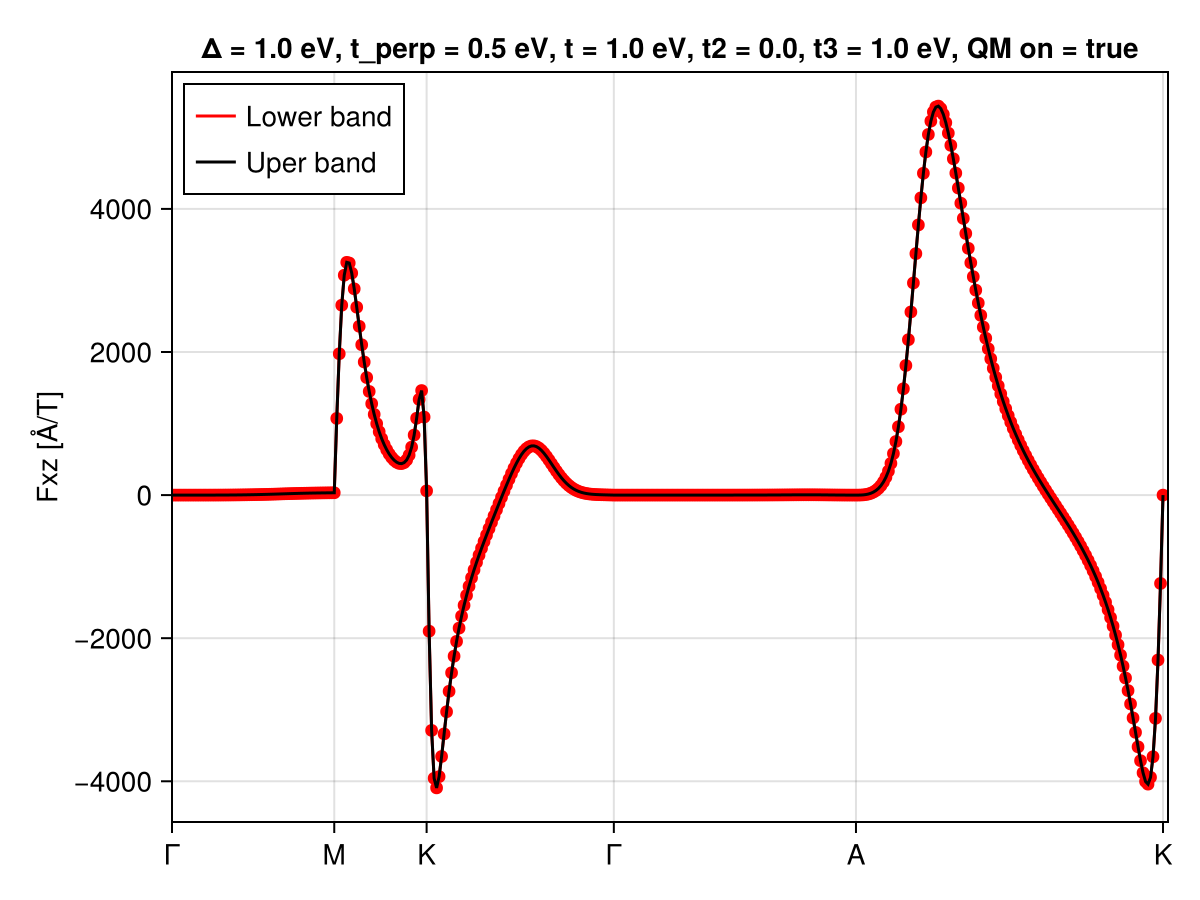

In [72]:

dir1 = :x
dir2 = :z
# Method reusing the OMM
yvals0_1, yvals0_2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1)
fig


## K - resolved quantities

In [18]:
using Brillouin, Bravais, BZpaths

In [16]:
function k_mesh_evals(quantity, p, R1, R2, R3, c_symb::Symbol; u0 = 0,  botbounds = [-0.5,-0.5], topbounds = [0.5,0.5], kpoints = 100)
    Gs = dualbasis([R1,R2,R3])
    N = floor(Int, kpoints^(1/3))
    uas = range(botbounds[1], topbounds[1], length=N)
    ubs = range(botbounds[2], topbounds[2], length=N)
    c = Optics_in_the_length_gauge.symb_to_ind(c_symb)
    u_param(ua,ub, c) = ifelse(c == 1, [u0,ua,ub], ifelse(c == 2, [ua,u0,ub], [ua,ub,u0]))
    aux_f(ua,ub,c) = Optics_in_the_length_gauge.transform_k(SVector(ua,ub,c), Gs)
    a, b = setdiff(1:3, [c])
    ka = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[a] for ua in uas, ub in ubs]
    kb = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[b] for ua in uas, ub in ubs]
    f(ua,ub) = quantity(p, Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c),Gs))
    Z = [f(ua,ub) for ua in uas, ub in ubs]
    return (a,b), ka, kb, Z
end

function plot_kresolved(kx, ky, Z, u0; label = "f(a, b)", titlelab = "")
    fig = Figure(size = (600, 500))
    ax = Axis(fig[1, 1], xlabel="ka [1/Å]", ylabel="kb [1/Å]", title = titlelab * ", uz = $(u0)")
    cmap = :RdBu#reverse(cgrad(:grays))  # CairoMakie built-in colormap, light-to-dark blues
    hm = surface!(ax, kx, ky, zeros(size(Z)),
                color=Z,
                shading=NoShading,
                colormap=cmap,
                colorrange=(-maximum(abs,Z), maximum(abs,Z)))
    Colorbar(fig[1, 2], hm, label=label)
    # ylims!(ax, -2π-π/2, 2π+π/2)
    fig
end

plot_kresolved (generic function with 1 method)

### Density of states

In [5]:
# compute k mesh


T = 10 
u0 = 0.01 # kz

a = 1.0
Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2, 0], a .* [0,0,1])
R1 = Rs[1]
R2 = Rs[2]
R3 = Rs[3]

kws = (T = T, fermi_surface = true)

p = modelpresets_FA(; μ = 0, t = 1 ,tp = 0, Δ = 0)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);


In [28]:
# compute k mesh
dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2.2 .* [-0.5,-0.5], topbounds = 2.2 .* [0.5,0.5], kpoints = 500000);

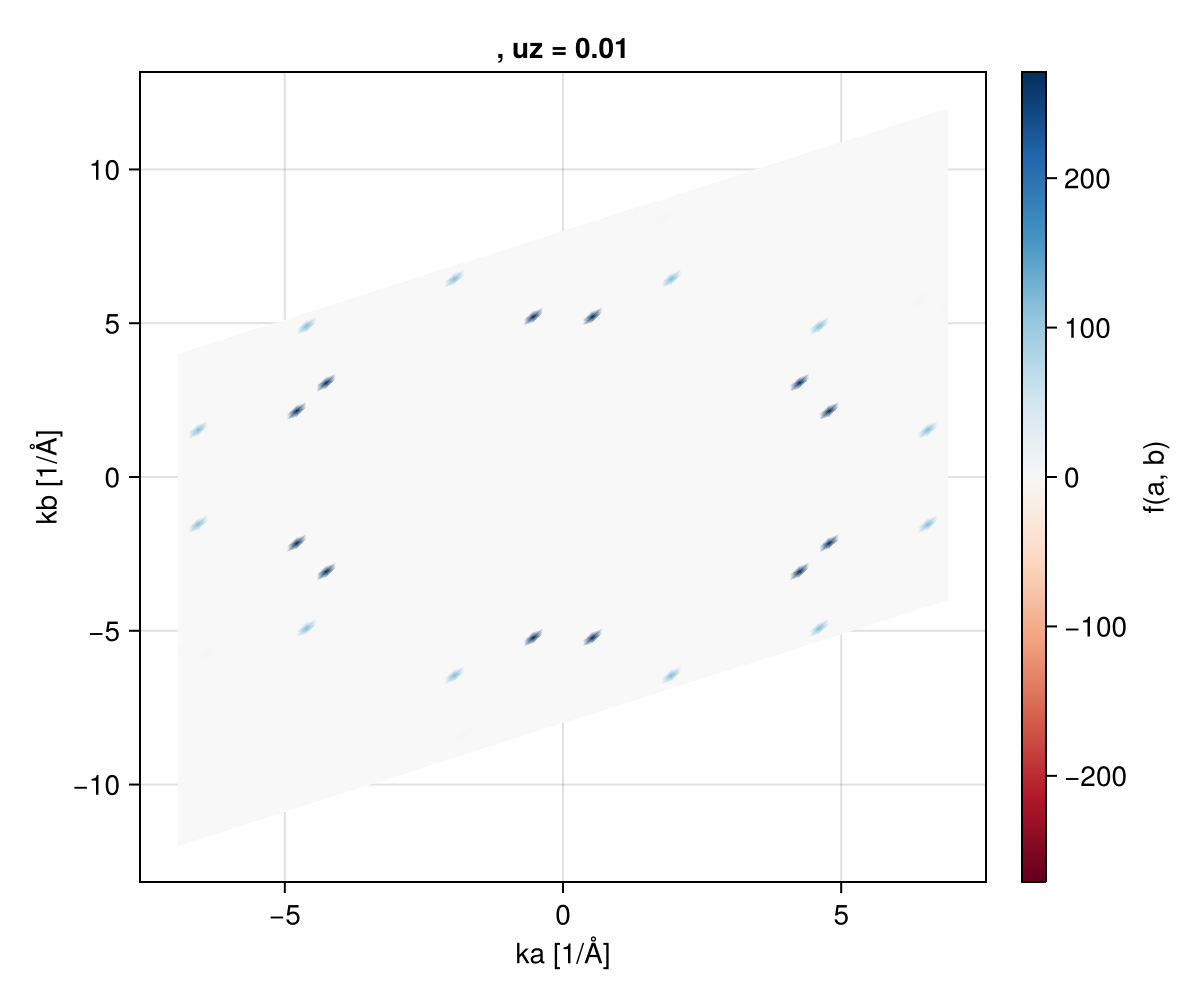

In [21]:
plot_kresolved(kx,ky,Z, u0) 

In [48]:
## Integrand

In [ ]:
# compute k mesh

T = 1
u0 = 0.0000

kws = (dirj = :x, dirE = :y, dirB = :z, T = T, fermi_surface = false, omega_MM_switch = false, PS_switch = true, QM_switch = true)

p = modelpresets_FA(; μ = 0, t = 1 ,tp = 0.5, Δ = 0.5)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);



### F

In [42]:
# compute k mesh

T = 1
u0 = 0.0000

kws = (dirj = :x, dirE = :y, dirB = :z, T = T, fermi_surface = false, omega_MM_switch = false, PS_switch = true, QM_switch = true)

p = modelpresets_FA(; μ = 0, t = 1 ,tp = 0.5, Δ = 0.5)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);



In [43]:
# compute k mesh
Fab(q) = Optics_in_the_length_gauge.F(comp_pres, q, :x, :y)
dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2.2 .* [-0.5,-0.5], topbounds = 2.2 .* [0.5,0.5], kpoints = 4000000);

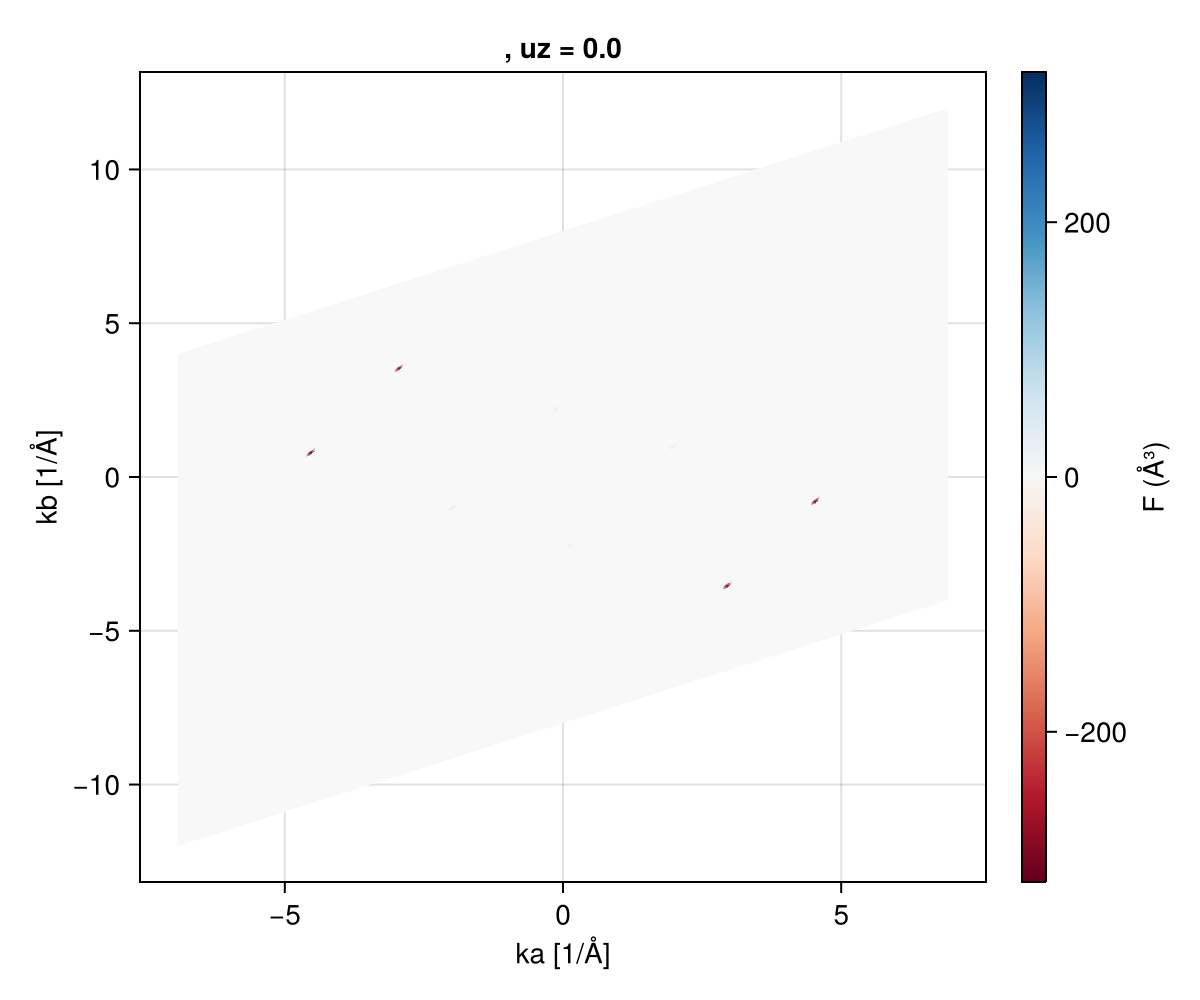

In [44]:
plot_kresolved(kx,ky,Z, u0, label = "F (Å³)") 